<a href="https://colab.research.google.com/github/josevargasmercado02/TareasCursos20B/blob/main/Caso1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intercepción de Misil — Ley de Persecución Pura

**Curso:** Física Computacional · **Tema:** Integración Numérica de EDOs
**Método:** Runge-Kutta de 4to Orden (RK4) · **Lenguaje:** Python 3

---

## 1. Descripción del Problema

Un misil superficie-aire es lanzado desde el origen y debe interceptar un **objetivo que no maniobra** volando horizontalmente a velocidad constante $v_T$ y altitud fija $H$. El misil sigue una **ley de guía de persecución pura**: su vector de empuje está siempre dirigido a lo largo de la *línea de visión* (LOS, por sus siglas en inglés) instantánea desde el misil hacia el objetivo.

---

## 2. Ecuaciones de Movimiento

Sea la posición del misil $\mathbf{r}_1(t) = (x(t),\, y(t))$ y la posición del objetivo $\mathbf{r}_2(t) = (v_T t,\, H)$.

### 2.1 Vector de la Línea de Visión (LOS)

$$\mathbf{R}(t) = \mathbf{r}_2(t) - \mathbf{r}_1(t) = \begin{pmatrix} v_T t - x \\ H - y \end{pmatrix}, \qquad R(t) = \|\mathbf{R}(t)\| = \sqrt{(v_T t - x)^2 + (H - y)^2}$$

### 2.2 Componentes de la Aceleración

La aceleración propulsiva actúa a lo largo de $\hat{\mathbf{R}} = \mathbf{R}/R$. La gravedad actúa en la dirección $-y$:

$$\ddot{x} = a\,\frac{v_T t - x}{R(t)}, \qquad \ddot{y} = a\,\frac{H - y}{R(t)} - g$$

### 2.3 Formulación de Espacio de Estados de Primer Orden

Definiendo el vector de estado $\mathbf{Y} = [x,\; v_x,\; y,\; v_y]^\top$:

$$\frac{d\mathbf{Y}}{dt} = \mathbf{f}(t,\mathbf{Y}) = \begin{pmatrix} v_x \\ a\,(v_T t - x)/R \\ v_y \\ a\,(H - y)/R - g \end{pmatrix}$$

---

## 3. Método Numérico — RK4

El esquema clásico de Runge-Kutta de 4to orden avanza el estado por un paso $h$:

$$\mathbf{k}_1 = \mathbf{f}(t_n,\; \mathbf{Y}_n)$$
$$\mathbf{k}_2 = \mathbf{f}\!\left(t_n + \tfrac{h}{2},\; \mathbf{Y}_n + \tfrac{h}{2}\mathbf{k}_1\right)$$
$$\mathbf{k}_3 = \mathbf{f}\!\left(t_n + \tfrac{h}{2},\; \mathbf{Y}_n + \tfrac{h}{2}\mathbf{k}_2\right)$$
$$\mathbf{k}_4 = \mathbf{f}(t_n + h,\; \mathbf{Y}_n + h\,\mathbf{k}_3)$$
$$\boxed{\mathbf{Y}_{n+1} = \mathbf{Y}_n + \frac{h}{6}\left(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4\right)}$$

Error de truncamiento local: $\mathcal{O}(h^5)$; error global: $\mathcal{O}(h^4)$.

---

## 4. Condiciones Terminales

| Condición | Criterio | Resultado |
|-----------|-----------|---------|
| **Intercepción** | $R(t) \leq \varepsilon$ | Éxito |
| **Impacto en el suelo** | $y(t) < 0$ y $t > t_{\min}$ | Falla |
| **Tiempo límite** | $t \geq t_f$ | Falla |

La singularidad $R \to 0$ se regulariza limitando $R \geq 10^{-6}$ m.

¡Impacto detectado en t = 3.426 s!
Punto de intercepción: x = 16.74 m, y = 29.71 m
Rapidez de intercepción: 21.23 m/s


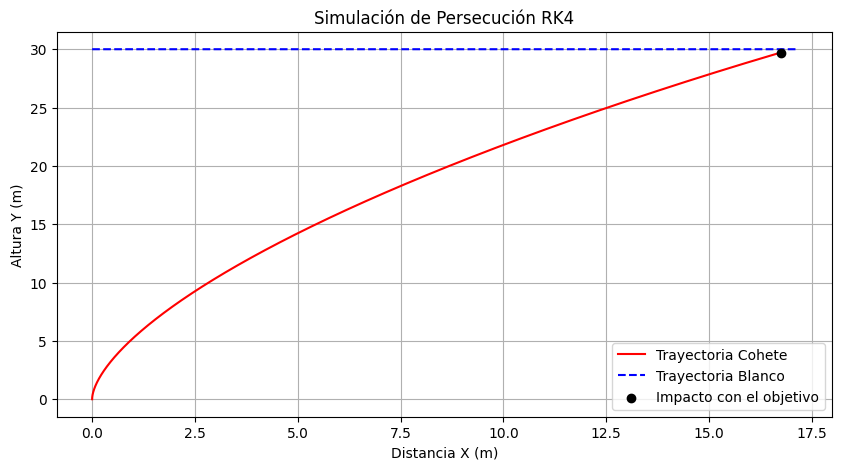

Para interceptar, vy0 debe estar en el intervalo: [0.34, 1.02] m/s
¡Ojo! a tiene intercepciones entre [12.71, 28.47] m/s², pero el intervalo NO es continuo (hay valores intermedios que fallan).
Para interceptar, v debe estar en el intervalo: [0.00, 11.69] m/s
Para interceptar, H debe estar en el intervalo: [5.00, 100.00] m


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Condiciones iniciales
a = 15       # aceleración del cohete
v = 5        # velocidad del blanco
H = 30       # altura
g = 9.81     # gravedad

x0, vx0 = 0.0, 0.0
y0, vy0 = 0.0, 0.5 # Velocidad inicial completamente vertical


# Método numérico Runge-Kutta de orden 4
def rk4(vy0_val, a_val, v_val, H_val):
    C = np.array([x0, vx0, y0, vy0_val], dtype=float)

    # Sistema de ecuaciones diferenciales
    def f(t, Y):
        x, vx, y, vy = Y
        R = np.sqrt((v_val*t - x)**2 + (H_val - y)**2)

        # Esto evita la singularidad (división por cero) justo en el impacto
        if R < 1e-6:
            R = 1e-6

        dx = vx
        dy = vy
        dvx = (a_val * (v_val*t - x)) / R
        dvy = (a_val * (H_val - y)) / R - g

        return np.array([dx, dvx, dy, dvy])

    t = 0       # tiempo inicial
    tf = 200    # límite de tiempo
    h = 0.001   # paso
    ep = 0.5    # Error permitido para intersección

    T = [t]
    X = [C[0]]
    Ypos = [C[2]]
    P0 = 2 # Definimos el estado por defecto si el cohete no alcanza el objetivo en el tiempo estipulado

    while t < tf:
        k1 = f(t, C)
        k2 = f(t + h/2, C + h*k1/2)
        k3 = f(t + h/2, C + h*k2/2)
        k4 = f(t + h, C + h*k3)

        C = C + h*(k1 + 2*k2 + 2*k3 + k4)/6
        t += h

        T.append(t)
        X.append(C[0])
        Ypos.append(C[2])

        R0 = np.sqrt((v_val*t - C[0])**2 + (H_val - C[2])**2)

        if R0 <= ep:
            P0 = 1 # El estado cambia si hay impacto con el objetivo
            break

        if C[2] < 0 and t > 0.1:
            P0 = 0 # El estado cambia si hay impacto con el suelo
            break

    vf = np.sqrt(C[1]**2 + C[3]**2) # Cálculo de la rapidez final

    # Retornamos un diccionario con todo empaquetado y nombrado
    return {
        "P0": P0,
        "x_final": C[0],
        "y_final": C[2],
        "t_final": t,
        "rapidez_final": vf,
        "T_hist": T,
        "X_hist": X,
        "Y_hist": Ypos
    }

# Ejecutamos RK4 con los parámetros impuestos
res = rk4(vy0, a, v, H)

# imprimimos el resultado del movimiento
if res["P0"] == 1:
    print(f"¡Impacto detectado en t = {res['t_final']:.3f} s!")
    print(f"Punto de intercepción: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")
    print(f"Rapidez de intercepción: {res['rapidez_final']:.2f} m/s")
elif res["P0"] == 0:
    print(f"El cohete se estrelló contra el suelo en t = {res['t_final']:.3f} s!")
    print(f"Punto de impacto: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")
else:
    print("El cohete no alcanzó el objetivo en el tiempo estipulado.")
    print(f"El punto final es: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")


# Gráfica
T_array = np.array(res["T_hist"])
X_blanco = v * T_array
Y_blanco = np.full_like(T_array, H)

plt.figure(figsize=(10, 5))
plt.plot(res["X_hist"], res["Y_hist"], label='Trayectoria Cohete', color='red')
plt.plot(X_blanco, Y_blanco, label='Trayectoria Blanco', color='blue', linestyle='--')

# Cambiamos el nombre del punto final dependiendo de lo que haya pasado durante el recorrido
if res["P0"] == 1:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Impacto con el objetivo')
elif res["P0"] == 0:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Impacto con el suelo')
else:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Tiempo límite alcanzado')

plt.xlabel('Distancia X (m)')
plt.ylabel('Altura Y (m)')
plt.title('Simulación de Persecución RK4')
plt.legend()
plt.grid(True)
plt.show()

# Análisis de intervalos
def analizar_intervalo(valores, resultados):
    validos = [val for val, p0 in zip(valores, resultados) if p0 == 1]
    return validos

experimentos = [
    ("vy0", "m/s", np.linspace(-20, 20, 60), lambda val: rk4(val, a, v, H)["P0"]),
    ("a", "m/s²", np.linspace(0, 30, 60), lambda val: rk4(vy0, val, v, H)["P0"]),
    ("v", "m/s", np.linspace(0, 30, 60), lambda val: rk4(vy0, a, val, H)["P0"]),
    ("H", "m", np.linspace(5, 100, 60), lambda val: rk4(vy0, a, v, val)["P0"]),
]

for var, unidad, valores, eval_rk4 in experimentos:
    res_barrido = [eval_rk4(val) for val in valores]
    validos = analizar_intervalo(valores, res_barrido)

    if validos:
        min_val = min(validos)
        max_val = max(validos)
        esperados = len([v for v in valores if min_val <= v <= max_val])
        if len(validos) == esperados:
            print(f"Para interceptar, {var} debe estar en el intervalo: [{min_val:.2f}, {max_val:.2f}] {unidad}")
        else:
            print(f"¡Ojo! {var} tiene intercepciones entre [{min_val:.2f}, {max_val:.2f}] {unidad}, pero el intervalo NO es continuo (hay valores intermedios que fallan).")
    else:
        print(f"No se encontró un intervalo de {var} que produzca intercepción.")

## Diseño del Experimento

### 5.1 — Simulación de Trayectoria Única

Se ejecuta una única integración RK4 con los parámetros físicos base definidos a continuación. El resultado clasifica el desenlace e imprime el estado terminal. Tanto la trayectoria del misil como la del objetivo se visualizan en los mismos ejes.

### 5.2 — Barridos de Parámetros 1-D e Intervalos de Validez

Cada parámetro físico ($v_{y,0}$, $a$, $v_T$, $H$) se barre de forma independiente sobre un rango predefinido (60 muestras cada uno) mientras que los tres restantes se mantienen en sus valores base.

| Parámetro              | Símbolo     | Unidad | Rango de barrido |
|------------------------|:-----------:|:------:|:----------------:|
| Velocidad vert. inicial| $v_{y,0}$   | m/s    | −20 → +20        |
| Aceleración de empuje  | $a$         | m/s²   | 0 → 30           |
| Velocidad del objetivo | $v_T$       | m/s    | 0 → 30           |
| Altitud del objetivo   | $H$         | m      | 5 → 100          |

¡Impacto detectado en t = 3.350 s!
Punto de intercepción: x = 16.25 m, y = 29.97 m


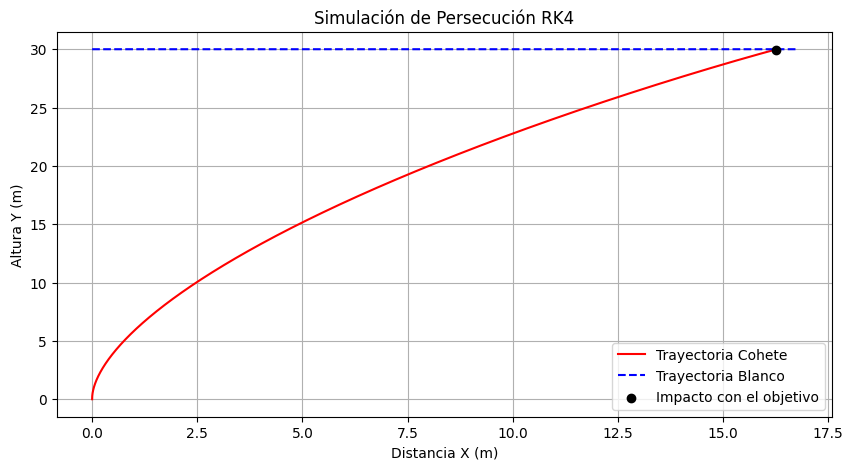

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
a = 15      # aceleración del cohete
v = 5       # velocidad del blanco
H = 30      # altura

# Condición inicial (vy0 = 1.0 como tenías en esta segunda celda)
vy0 = 1.0

# Reutilizamos la función rk4 definida en la primera celda
res = rk4(vy0, a, v, H)

# Imprimimos el resultado de la evaluación
P0 = res["P0"]
if P0 == 1:
    print(f"¡Impacto detectado en t = {res['t_final']:.3f} s!")
    print(f"Punto de intercepción: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")
elif P0 == 0:
    print(f"El cohete se estrelló contra el suelo en t = {res['t_final']:.3f} s!")
    print(f"Punto de impacto: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")
else:
    print("El cohete no alcanzó el objetivo en el tiempo estipulado.")
    print(f"El punto final es: x = {res['x_final']:.2f} m, y = {res['y_final']:.2f} m")

# Gráfica
T_array = np.array(res["T_hist"])
X_blanco = v * T_array
Y_blanco = np.full_like(T_array, H)

plt.figure(figsize=(10, 5))
plt.plot(res["X_hist"], res["Y_hist"], label='Trayectoria Cohete', color='red')
plt.plot(X_blanco, Y_blanco, label='Trayectoria Blanco', color='blue', linestyle='--')

# Cambiamos el marcador del punto final dependiendo del estado
if P0 == 1:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Impacto con el objetivo')
elif P0 == 0:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Impacto con el suelo')
else:
    plt.scatter([res["X_hist"][-1]], [res["Y_hist"][-1]], color='black', zorder=5, label='Tiempo límite alcanzado')

plt.xlabel('Distancia X (m)')
plt.ylabel('Altura Y (m)')
plt.title('Simulación de Persecución RK4')
plt.legend()
plt.grid(True)
plt.show()
